In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("14-income_evaluation.csv")

In [15]:
data.head()

,age,workclass,finalweight,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
data.shape

(32561, 15)

In [7]:
data.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')

In [8]:
col_names = ["age", "workclass", "finalweight", "education", "education_num", "marital_status", "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"]

In [9]:
data.columns = col_names

In [10]:
data.columns

Index(['age', 'workclass', 'finalweight', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   finalweight     32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [12]:
data.describe()

,age,finalweight,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [13]:
data.isnull().sum()

age               0
workclass         0
finalweight       0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [18]:
categorical = [col for col in data.columns if data[col].dtype == "O"]
numerical = [col for col in data.columns if data[col].dtype != "O"]

In [19]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [20]:
numerical

['age',
 'finalweight',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']

In [22]:
data[categorical].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [23]:
data[numerical].head()

,age,finalweight,education_num,capital_gain,capital_loss,hours_per_week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40


In [24]:
for col in categorical:
    print(data[col].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      

In [25]:
data["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

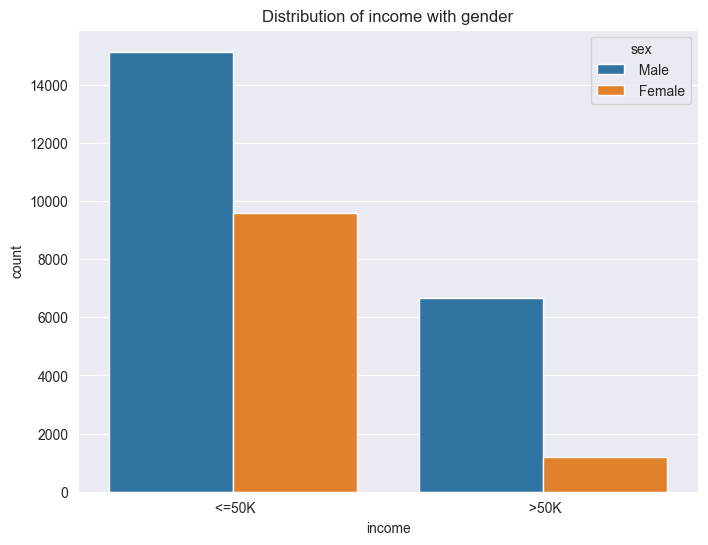

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
ax = sns.countplot(x="income", data=data, hue="sex")
ax.set_title("Distribution of income with gender")
plt.show()

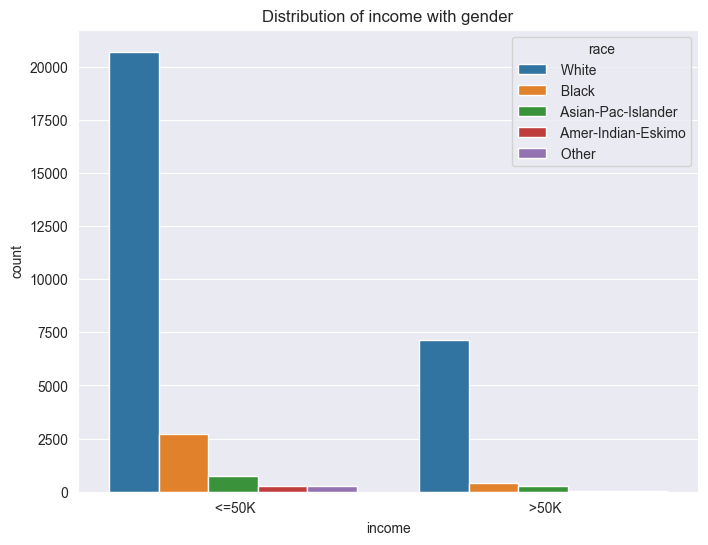

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
ax = sns.countplot(x="income", data=data, hue="race")
ax.set_title("Distribution of income with gender")
plt.show()

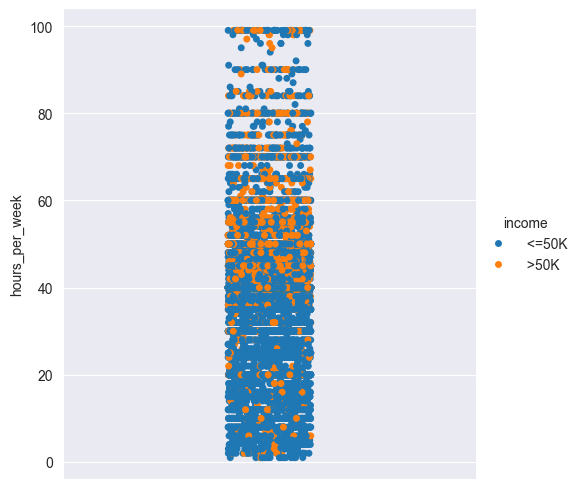

In [33]:
sns.catplot(y=data["hours_per_week"], hue="income", data=data)
plt.show()

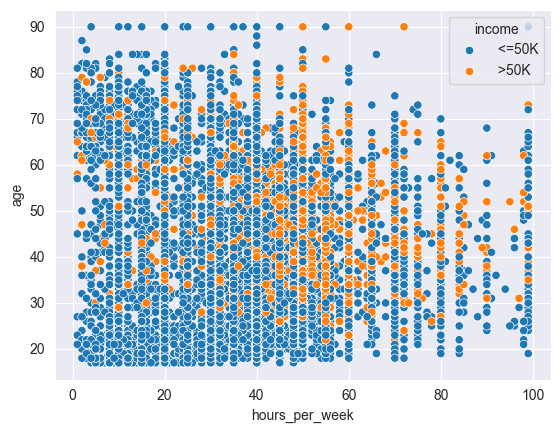

In [34]:
sns.scatterplot(x=data["hours_per_week"], y=data["age"], hue="income", data=data)
plt.show()

In [39]:
over_40_hours = data[data["hours_per_week"]>40]
under_40_hours = data[data["hours_per_week"]<=40]

In [40]:
over_40_hours.shape

(9581, 15)

In [41]:
under_40_hours.shape

(22980, 15)

In [42]:
over_40_hours["income"].value_counts()

income
<=50K    5725
>50K     3856
Name: count, dtype: int64

In [43]:
under_40_hours["income"].value_counts()

income
<=50K    18995
>50K      3985
Name: count, dtype: int64

In [44]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [45]:
data["workclass"].unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [46]:
data["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [49]:
data["workclass"] = data["workclass"].replace(" ?", np.nan)

In [50]:
data["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [51]:
data["education"].unique()

array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th',
       ' Preschool', ' 12th'], dtype=object)

In [52]:
data["marital_status"].unique()

array([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'], dtype=object)

In [53]:
data["occupation"].unique()

array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'], dtype=object)

In [54]:
data["occupation"] = data["occupation"].replace(" ?", np.nan)

In [55]:
data["occupation"].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [56]:
data["relationship"].unique()

array([' Not-in-family', ' Husband', ' Wife', ' Own-child', ' Unmarried',
       ' Other-relative'], dtype=object)

In [57]:
data["race"].unique()

array([' White', ' Black', ' Asian-Pac-Islander', ' Amer-Indian-Eskimo',
       ' Other'], dtype=object)

In [58]:
data["native_country"].unique()

array([' United-States', ' Cuba', ' Jamaica', ' India', ' ?', ' Mexico',
       ' South', ' Puerto-Rico', ' Honduras', ' England', ' Canada',
       ' Germany', ' Iran', ' Philippines', ' Italy', ' Poland',
       ' Columbia', ' Cambodia', ' Thailand', ' Ecuador', ' Laos',
       ' Taiwan', ' Haiti', ' Portugal', ' Dominican-Republic',
       ' El-Salvador', ' France', ' Guatemala', ' China', ' Japan',
       ' Yugoslavia', ' Peru', ' Outlying-US(Guam-USVI-etc)', ' Scotland',
       ' Trinadad&Tobago', ' Greece', ' Nicaragua', ' Vietnam', ' Hong',
       ' Ireland', ' Hungary', ' Holand-Netherlands'], dtype=object)

In [59]:
data["native_country"] = data["native_country"].replace(" ?", np.nan)

In [60]:
data.isnull().sum()

age                  0
workclass         1836
finalweight          0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

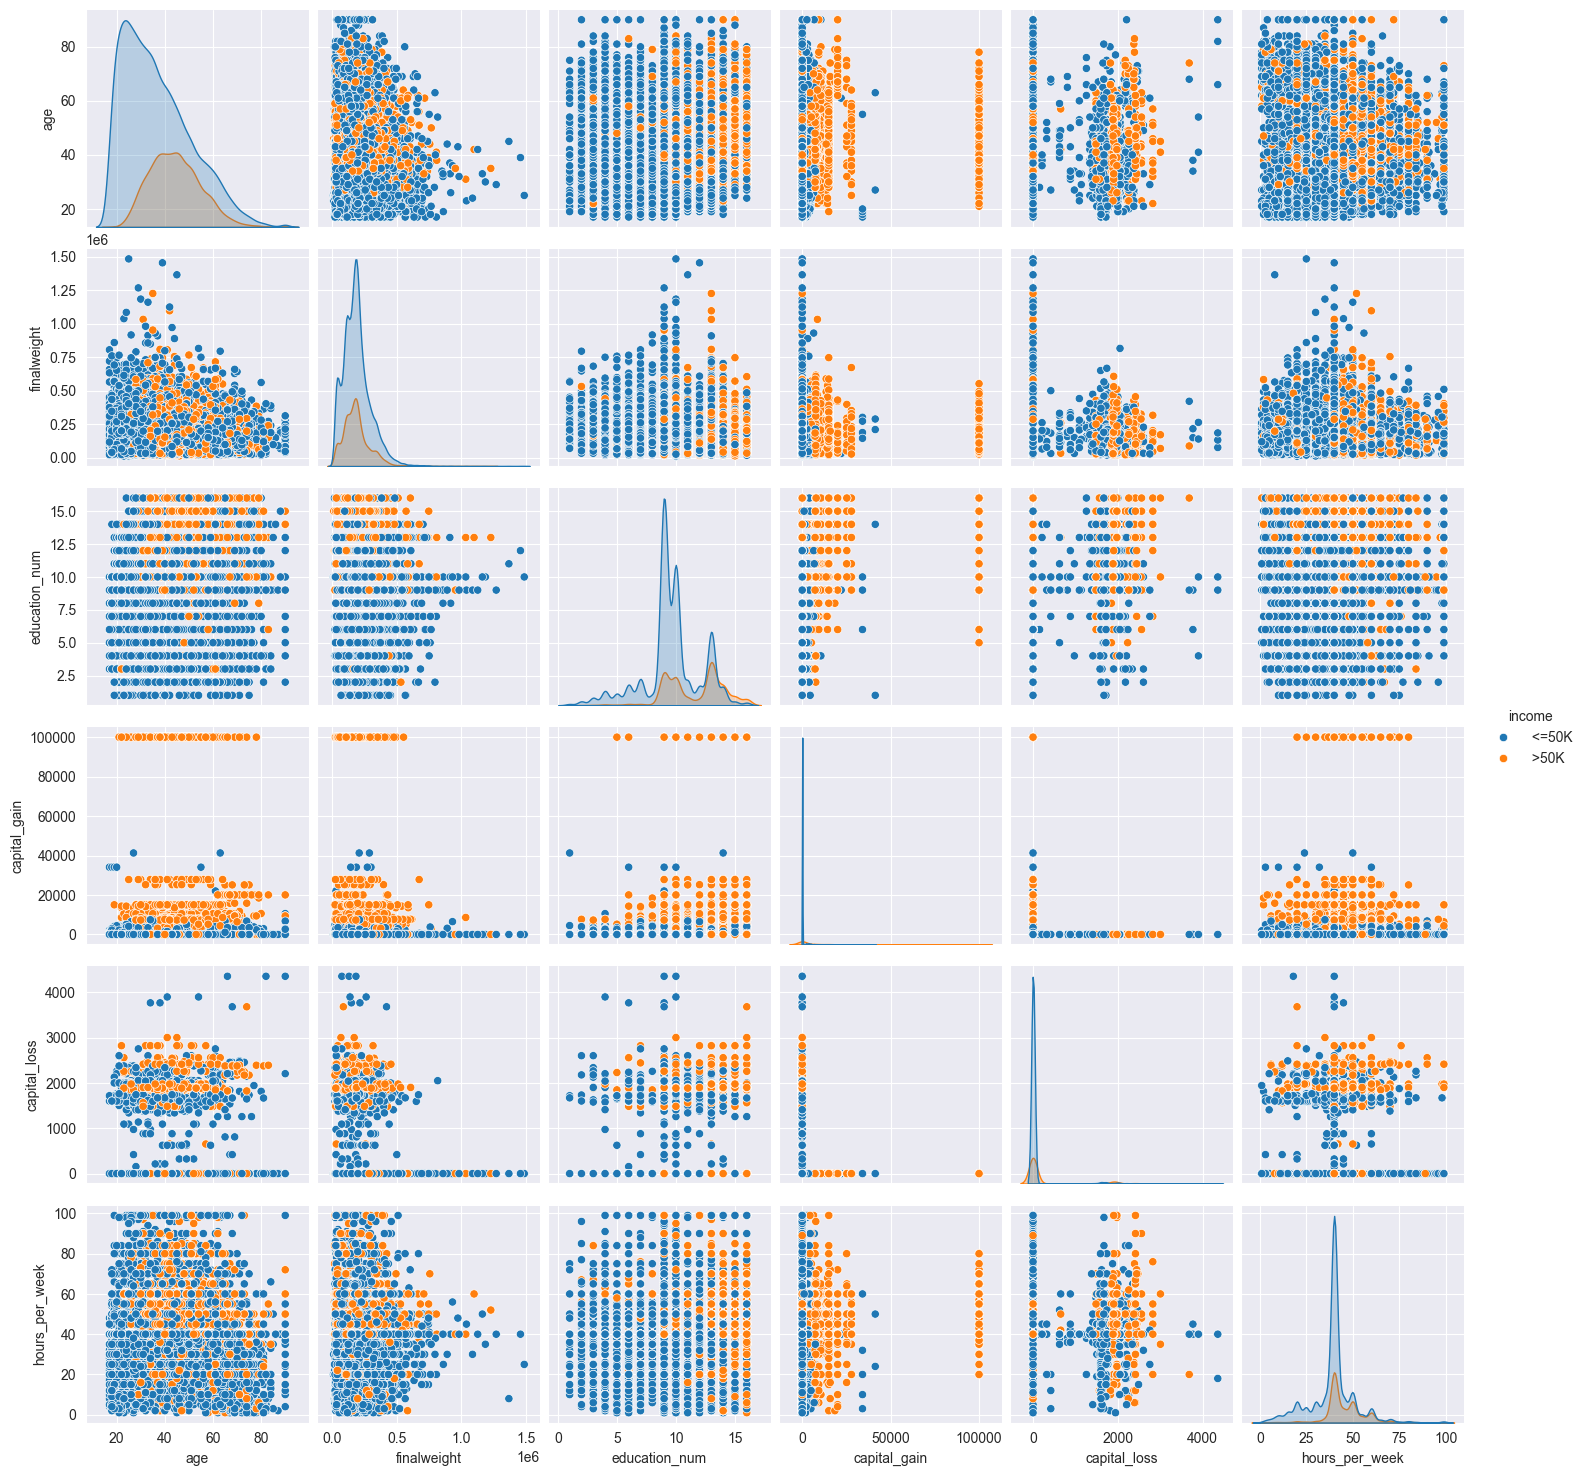

In [62]:
sns.pairplot(data, hue="income")
plt.show()

In [63]:
X = data.drop("income", axis=1)
y = data["income"]

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [65]:
categorical = [col for col in X_train.columns if X_train[col].dtype == "O"]

In [70]:
X_train[categorical].isnull().sum()

workclass         1262
education            0
marital_status       0
occupation        1265
relationship         0
race                 0
sex                  0
native_country     392
dtype: int64

In [71]:
X_test[categorical].isnull().sum()

workclass         574
education           0
marital_status      0
occupation        578
relationship        0
race                0
sex                 0
native_country    191
dtype: int64

In [73]:
X_train["workclass"].mode()[0]

' Private'

In [74]:
for i in [X_train, X_test]:
    i["workclass"] = i["workclass"].fillna(X_train["workclass"].mode()[0])
    i["occupation"] = i["occupation"].fillna(X_train["occupation"].mode()[0])
    i["native_country"] = i["native_country"].fillna(X_train["native_country"].mode()[0])

In [75]:
X_train[categorical].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
dtype: int64

In [76]:
X_test[categorical].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
dtype: int64

In [77]:
# encoding

In [78]:
X_train[categorical].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country
32174,Self-emp-not-inc,Bachelors,Never-married,Sales,Not-in-family,White,Male,United-States
2680,Local-gov,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male,El-Salvador
10874,Private,Some-college,Widowed,Exec-managerial,Unmarried,White,Female,United-States
25028,Private,9th,Married-civ-spouse,Craft-repair,Husband,Other,Male,Mexico
25881,Self-emp-inc,Bachelors,Married-civ-spouse,Adm-clerical,Husband,White,Male,United-States


In [79]:
data[categorical].nunique()

workclass          8
education         16
marital_status     7
occupation        14
relationship       6
race               5
sex                2
native_country    41
dtype: int64

In [80]:
y_train

32174     <=50K
2680      <=50K
10874     <=50K
25028     <=50K
25881     <=50K
          ...  
16247     <=50K
2693      <=50K
8076      <=50K
20213     <=50K
7624       >50K
Name: income, Length: 22792, dtype: object

In [126]:
# there are many unique values in native_country. if we do one hot encoding it might work but it might get complicated
# because there will be many columns and it may lead to overfitting or underperforming generally
# so i will do target encoding for native country and one hot encoding for the rest.
# for target encoding i will get the mean of every unique value and replace it with them

In [81]:
y_train_binary = y_train.apply(lambda x: 1 if x.strip() == ">50K" else 0)

In [88]:
target_means = y_train_binary.groupby(X_train["native_country"]).mean()
target_means

native_country
Cambodia                      0.363636
Canada                        0.287500
China                         0.280702
Columbia                      0.046512
Cuba                          0.276923
Dominican-Republic            0.023810
Ecuador                       0.157895
El-Salvador                   0.129032
England                       0.301587
France                        0.368421
Germany                       0.333333
Greece                        0.222222
Guatemala                     0.022727
Haiti                         0.120000
Honduras                      0.000000
Hong                          0.333333
Hungary                       0.250000
India                         0.347826
Iran                          0.423077
Ireland                       0.076923
Italy                         0.280000
Jamaica                       0.109091
Japan                         0.382979
Laos                          0.166667
Mexico                        0.062907
Nicaragua 

In [90]:
X_train["native_country_encoded"] = X_train["native_country"].map(target_means)
X_train["native_country_encoded"] = X_train["native_country_encoded"].fillna(y_train_binary.mean())

X_test["native_country_encoded"] = X_test["native_country"].map(target_means)
X_test["native_country_encoded"] = X_test["native_country_encoded"].fillna(y_train_binary.mean())

In [91]:
X_train.head()

,age,workclass,finalweight,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,native_country_encoded
32174,44,Self-emp-not-inc,157217,Bachelors,13,Never-married,Sales,Not-in-family,White,Male,0,0,42,United-States,0.247311
2680,26,Local-gov,336969,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,28,El-Salvador,0.129032
10874,53,Private,233369,Some-college,10,Widowed,Exec-managerial,Unmarried,White,Female,0,0,40,United-States,0.247311
25028,30,Private,348618,9th,5,Married-civ-spouse,Craft-repair,Husband,Other,Male,0,0,40,Mexico,0.062907
25881,50,Self-emp-inc,140516,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,0.247311


In [92]:
X_train = X_train.drop("native_country", axis=1)
X_test = X_test.drop("native_country", axis=1)

In [93]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [94]:
one_hot_categories = [
 'workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
]

In [95]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [106]:
encoder = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), one_hot_categories)
    ], remainder="passthrough"
)

In [107]:
X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

In [105]:
X_train_enc #Sparse_output=False later

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 276437 stored elements and shape (22792, 65)>

In [108]:
X_train_enc

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 4.20000000e+01, 2.47311312e-01],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 2.80000000e+01, 1.29032258e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 4.00000000e+01, 2.47311312e-01],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 5.00000000e+01, 2.47311312e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.57900000e+03, 4.00000000e+01, 2.47311312e-01],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 4.00000000e+01, 2.47311312e-01]],
      shape=(22792, 65))

In [109]:
columns = encoder.get_feature_names_out()

In [110]:
columns

array(['categorical__workclass_ Federal-gov',
       'categorical__workclass_ Local-gov',
       'categorical__workclass_ Never-worked',
       'categorical__workclass_ Private',
       'categorical__workclass_ Self-emp-inc',
       'categorical__workclass_ Self-emp-not-inc',
       'categorical__workclass_ State-gov',
       'categorical__workclass_ Without-pay',
       'categorical__education_ 10th', 'categorical__education_ 11th',
       'categorical__education_ 12th', 'categorical__education_ 1st-4th',
       'categorical__education_ 5th-6th',
       'categorical__education_ 7th-8th', 'categorical__education_ 9th',
       'categorical__education_ Assoc-acdm',
       'categorical__education_ Assoc-voc',
       'categorical__education_ Bachelors',
       'categorical__education_ Doctorate',
       'categorical__education_ HS-grad',
       'categorical__education_ Masters',
       'categorical__education_ Preschool',
       'categorical__education_ Prof-school',
       'categorical__e

In [111]:
X_train = pd.DataFrame(X_train_enc, columns=columns, index=X_train.index)
X_test = pd.DataFrame(X_test_enc, columns=columns, index=X_test.index)

In [112]:
X_train

,categorical__workclass_ Federal-gov,categorical__workclass_ Local-gov,categorical__workclass_ Never-worked,categorical__workclass_ Private,categorical__workclass_ Self-emp-inc,categorical__workclass_ Self-emp-not-inc,categorical__workclass_ State-gov,categorical__workclass_ Without-pay,categorical__education_ 10th,categorical__education_ 11th,...,categorical__race_ White,categorical__sex_ Female,categorical__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
32174,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,44.0,157217.0,13.0,0.0,0.0,42.0,0.247311
2680,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,26.0,336969.0,13.0,0.0,0.0,28.0,0.129032
10874,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,53.0,233369.0,10.0,0.0,0.0,40.0,0.247311
25028,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,30.0,348618.0,5.0,0.0,0.0,40.0,0.062907
25881,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,50.0,140516.0,13.0,0.0,0.0,40.0,0.247311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16247,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,36.0,376455.0,11.0,0.0,0.0,38.0,0.247311
2693,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,24.0,145964.0,13.0,0.0,0.0,40.0,0.247311
8076,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,50.0,136913.0,9.0,0.0,0.0,50.0,0.247311
20213,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,25.0,182227.0,9.0,0.0,1579.0,40.0,0.247311


In [115]:
X_test

,categorical__workclass_ Federal-gov,categorical__workclass_ Local-gov,categorical__workclass_ Never-worked,categorical__workclass_ Private,categorical__workclass_ Self-emp-inc,categorical__workclass_ Self-emp-not-inc,categorical__workclass_ State-gov,categorical__workclass_ Without-pay,categorical__education_ 10th,categorical__education_ 11th,...,categorical__race_ White,categorical__sex_ Female,categorical__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
10125,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,47.0,182752.0,9.0,0.0,0.0,35.0,0.423077
11478,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,73.0,161027.0,3.0,0.0,0.0,20.0,0.247311
4224,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,18.0,152182.0,10.0,0.0,0.0,25.0,0.247311
6592,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,66.0,284021.0,9.0,0.0,0.0,40.0,0.247311
21910,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,39.0,261504.0,8.0,0.0,0.0,40.0,0.247311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31624,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,29.0,261725.0,13.0,0.0,0.0,35.0,0.247311
1488,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,57.0,278763.0,9.0,0.0,0.0,40.0,0.247311
8725,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,48.0,334409.0,13.0,0.0,0.0,50.0,0.247311
11150,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,37.0,302604.0,10.0,0.0,0.0,40.0,0.247311


In [116]:
cols = X_train.columns

In [127]:
# we don't actually need scaling in dt algortihms but let's do it because we will introduce robust scaler
# robust scaler is different than standardscaler and it is designed to handle outliers.

In [119]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler() # with outlier

In [120]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [122]:
X_train = pd.DataFrame(X_train, columns=cols)

In [123]:
X_train

,categorical__workclass_ Federal-gov,categorical__workclass_ Local-gov,categorical__workclass_ Never-worked,categorical__workclass_ Private,categorical__workclass_ Self-emp-inc,categorical__workclass_ Self-emp-not-inc,categorical__workclass_ State-gov,categorical__workclass_ Without-pay,categorical__education_ 10th,categorical__education_ 11th,...,categorical__race_ White,categorical__sex_ Female,categorical__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.35,-0.175622,1.000000,0.0,0.0,0.4,0.000000
1,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.55,1.335801,1.000000,0.0,0.0,-2.4,-0.118279
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,0.80,0.464693,0.000000,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.0,0.0,0.0,-0.35,1.433750,-1.666667,0.0,0.0,0.0,-0.184405
4,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.65,-0.316050,1.000000,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22787,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.05,1.667814,0.333333,0.0,0.0,-0.4,0.000000
22788,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.65,-0.270241,1.000000,0.0,0.0,0.0,0.000000
22789,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.65,-0.346345,-0.333333,0.0,0.0,2.0,0.000000
22790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.60,0.034672,-0.333333,0.0,1579.0,0.0,0.000000


In [124]:
X_test = pd.DataFrame(X_test, columns=cols)

In [125]:
X_test

,categorical__workclass_ Federal-gov,categorical__workclass_ Local-gov,categorical__workclass_ Never-worked,categorical__workclass_ Private,categorical__workclass_ Self-emp-inc,categorical__workclass_ Self-emp-not-inc,categorical__workclass_ State-gov,categorical__workclass_ Without-pay,categorical__education_ 10th,categorical__education_ 11th,...,categorical__race_ White,categorical__sex_ Female,categorical__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,0.50,0.039086,-0.333333,0.0,0.0,-1.0,0.175766
1,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.80,-0.143586,-2.333333,0.0,0.0,-4.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,-0.95,-0.217958,0.000000,0.0,0.0,-3.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,1.45,0.890594,-0.333333,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,0.10,0.701263,-0.666667,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9764,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,-0.40,0.703121,1.000000,0.0,0.0,-1.0,0.000000
9765,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,1.00,0.846383,-0.333333,0.0,0.0,0.0,0.000000
9766,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,0.55,1.314276,1.000000,0.0,0.0,2.0,0.000000
9767,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,0.00,1.046847,0.000000,0.0,0.0,0.0,0.000000


In [128]:
# training

In [129]:
from sklearn.ensemble import RandomForestClassifier

In [130]:
rfc = RandomForestClassifier(n_estimators=10, random_state=15)
rfc.fit(X_train, y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [131]:
y_pred = rfc.predict(X_test)

In [132]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [133]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.8538233186610708
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7444
        >50K       0.74      0.60      0.66      2325

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.78      9769
weighted avg       0.85      0.85      0.85      9769

[[6950  494]
 [ 934 1391]]


In [134]:
rfc = RandomForestClassifier(n_estimators=100, random_state=15)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.8629337700890573
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7444
        >50K       0.75      0.64      0.69      2325

    accuracy                           0.86      9769
   macro avg       0.82      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769

[[6931  513]
 [ 826 1499]]


In [135]:
rfc.feature_importances_

array([5.69055082e-03, 5.99724101e-03, 0.00000000e+00, 1.12368919e-02,
       5.95071218e-03, 8.91584273e-03, 4.44950659e-03, 1.56222107e-05,
       1.43250082e-03, 2.06212244e-03, 7.56054267e-04, 2.47339516e-04,
       6.20143042e-04, 1.74701664e-03, 9.28370165e-04, 2.64825643e-03,
       2.92500662e-03, 1.18834812e-02, 3.23796318e-03, 8.75179388e-03,
       8.46728337e-03, 4.67159279e-05, 4.58505562e-03, 5.54684103e-03,
       7.22921226e-03, 4.55704258e-04, 6.17226949e-02, 8.59519893e-04,
       2.66463955e-02, 1.51187990e-03, 1.65333428e-03, 6.01740973e-03,
       1.25865119e-05, 7.18922808e-03, 1.94907607e-02, 4.62408780e-03,
       3.23039158e-03, 4.70621344e-03, 7.71451124e-03, 1.00623188e-04,
       1.03969798e-02, 3.37451763e-03, 7.44332386e-03, 4.98338169e-03,
       4.99524888e-03, 4.15588436e-02, 9.79975556e-03, 1.46458315e-03,
       1.00803184e-02, 4.03157165e-03, 1.00765407e-02, 1.36690237e-03,
       3.32325527e-03, 5.12576566e-03, 9.26582257e-04, 7.11168066e-03,
      

In [138]:
feature_scores = pd.Series(rfc.feature_importances_, index=X_train.columns).sort_values(ascending = False)

In [139]:
feature_scores

remainder__finalweight                      0.160516
remainder__age                              0.151197
remainder__capital_gain                     0.093268
remainder__hours_per_week                   0.084478
remainder__education_num                    0.067521
                                              ...   
categorical__occupation_ Priv-house-serv    0.000101
categorical__education_ Preschool           0.000047
categorical__workclass_ Without-pay         0.000016
categorical__occupation_ Armed-Forces       0.000013
categorical__workclass_ Never-worked        0.000000
Length: 65, dtype: float64

In [140]:
feature_scores.tail(10)

categorical__marital_status_ Married-spouse-absent    0.000860
categorical__education_ 12th                          0.000756
categorical__education_ 5th-6th                       0.000620
categorical__marital_status_ Married-AF-spouse        0.000456
categorical__education_ 1st-4th                       0.000247
categorical__occupation_ Priv-house-serv              0.000101
categorical__education_ Preschool                     0.000047
categorical__workclass_ Without-pay                   0.000016
categorical__occupation_ Armed-Forces                 0.000013
categorical__workclass_ Never-worked                  0.000000
dtype: float64

In [141]:
X_train = X_train.drop([
    "categorical__marital_status_ Married-spouse-absent",
    "categorical__education_ 12th",
    "categorical__education_ 5th-6th",
    "categorical__marital_status_ Married-AF-spouse",
    "categorical__education_ 1st-4th",
    "categorical__occupation_ Priv-house-serv",
    "categorical__education_ Preschool",
    "categorical__workclass_ Without-pay",
    "categorical__occupation_ Armed-Forces",
    "categorical__workclass_ Never-worked"

], axis=1
)

In [142]:
X_test = X_test.drop([
    "categorical__marital_status_ Married-spouse-absent",
    "categorical__education_ 12th",
    "categorical__education_ 5th-6th",
    "categorical__marital_status_ Married-AF-spouse",
    "categorical__education_ 1st-4th",
    "categorical__occupation_ Priv-house-serv",
    "categorical__education_ Preschool",
    "categorical__workclass_ Without-pay",
    "categorical__occupation_ Armed-Forces",
    "categorical__workclass_ Never-worked"
], axis=1
)

In [143]:
rfc = RandomForestClassifier(n_estimators=100, random_state=15)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.8643668748080663
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7444
        >50K       0.75      0.65      0.69      2325

    accuracy                           0.86      9769
   macro avg       0.82      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769

[[6940  504]
 [ 821 1504]]


In [145]:
# hyperparameter tuning

In [146]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

In [147]:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

rf_params = {
    "n_estimators": [100, 200, 500, 800, 1000],
    "max_depth": [3, 5, 7, 9, 15, None],
    "max_features": ["sqrt", "log2",5 ,6, 7, 8],
    "min_samples_split": [2, 8, 15, 20],
}

In [149]:
rfc = RandomForestClassifier()

In [150]:
rscv = RandomizedSearchCV(estimator= rfc, param_distributions=rf_params, cv=3, n_jobs=-1)
rscv.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_split': [2, 8, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [151]:
y_pred = rscv.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.8662094380182209
              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.92      7444
        >50K       0.78      0.61      0.68      2325

    accuracy                           0.87      9769
   macro avg       0.83      0.78      0.80      9769
weighted avg       0.86      0.87      0.86      9769

[[7054  390]
 [ 917 1408]]


In [152]:
rscv.best_params_

{'n_estimators': 800,
 'min_samples_split': 15,
 'max_features': 7,
 'max_depth': 15}